Airbnb Price Prediction

In [185]:
"""
====================================================
Importing Require Libraries and Loading the Datasets
==================================================== 
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [186]:
df_property = pd.read_csv("C:/Users/ACER/Downloads/PropertyData.csv")
df_address = pd.read_csv("C:/Users/ACER/Downloads/AddressData.csv")

In [187]:
"""
====================================================
                Data Preprocessing
==================================================== 
"""
df_property.head()

,Unnamed: 0,property_id,listing_url,name,desc,rules,property_type,room_type,bed_type,min_nights,...,accomodates,total_bedrooms,total_beds,price,deposit,cleaning_fee,extra_people,guests_included,review_count,image
0,0,1003530,https://www.airbnb.com/rooms/1003530,New York City - Upper West Side Apt,"Murphy bed, optional second bedroom available....",No smoking is permitted in the apartment. All ...,Apartment,Private room,Real Bed,12,...,2,1,1,135,1,1,0,1,70,https://a0.muscache.com/im/pictures/15074036/a...
1,1,10133554,https://www.airbnb.com/rooms/10133554,Double and triple rooms Blue mosque,We are on the central city Blue mosque 5 minu...,NaN,Bed and breakfast,Private room,Real Bed,1,...,3,1,2,121,2,2,0,1,29,https://a0.muscache.com/im/pictures/68de30b5-e...
2,2,10059872,https://www.airbnb.com/rooms/10059872,"Soho Cozy, Spacious and Convenient","Clean, fully furnish, Spacious 1 bedroom flat ...",NaN,Apartment,Entire home/apt,Real Bed,4,...,3,1,2,699,2,2,0,1,3,https://a0.muscache.com/im/pictures/4533a1dc-6...
3,3,10084023,https://www.airbnb.com/rooms/10084023,City center private room with bed,House is located 5mins walk from Sham Shui Po ...,"1. 禁止吸煙, 只限女生入住 (除得到批准) No smoking and only fe...",Guesthouse,Private room,Futon,1,...,1,1,1,181,1,1,100,1,81,https://a0.muscache.com/im/pictures/e6275515-7...
4,4,10091713,https://www.airbnb.com/rooms/10091713,Surry Hills Studio - Your Perfect Base in Sydney,"This spacious, light filled studio has everyth...","No smoking: No smoking any substance, includi...",Apartment,Entire home/apt,Real Bed,10,...,2,0,1,181,1,1,0,1,64,https://a0.muscache.com/im/pictures/f8eaba4e-d...


In [188]:
df_property.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5555 entries, 0 to 5554
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5555 non-null   int64 
 1   property_id          5555 non-null   int64 
 2   listing_url          5555 non-null   object
 3   name                 5547 non-null   object
 4   desc                 5460 non-null   object
 5   rules                3270 non-null   object
 6   property_type        5555 non-null   object
 7   room_type            5555 non-null   object
 8   bed_type             5555 non-null   object
 9   min_nights           5555 non-null   int64 
 10  max_nights           5555 non-null   int64 
 11  cancellation_policy  5555 non-null   object
 12  accomodates          5555 non-null   int64 
 13  total_bedrooms       5555 non-null   int64 
 14  total_beds           5555 non-null   int64 
 15  price                5555 non-null   int64 
 16  deposi

In [189]:
df_property.shape

(5555, 22)

In [190]:
df_address.head()

,Unnamed: 0,_id,street,suburb,government_area,market,country,country_code,location_type,is_location_exact,latitude,longitude
0,0,1003530,"New York, NY, United States",Manhattan,Upper West Side,New York,United States,US,Point,False,-73.96523,40.79962
1,1,10133554,"Fatih , İstanbul, Turkey",Fatih,Fatih,Istanbul,Turkey,TR,Point,False,28.98009,41.00620
2,2,10059872,"Hong Kong, Hong Kong Island, Hong Kong",Central & Western District,Central & Western,Hong Kong,Hong Kong,HK,Point,True,114.15027,22.28158
3,3,10084023,"Hong Kong , 九龍, Hong Kong",Sham Shui Po District,Sham Shui Po,Hong Kong,Hong Kong,HK,Point,True,114.16690,22.33140
4,4,10091713,"Surry Hills, NSW, Australia",Darlinghurst,Sydney,Sydney,Australia,AU,Point,True,151.21554,-33.88029


Handling Missing Data

In [191]:
df_property.isna().sum()

Unnamed: 0                0
property_id               0
listing_url               0
name                      8
desc                     95
rules                  2285
property_type             0
room_type                 0
bed_type                  0
min_nights                0
max_nights                0
cancellation_policy       0
accomodates               0
total_bedrooms            0
total_beds                0
price                     0
deposit                   0
cleaning_fee              0
extra_people              0
guests_included           0
review_count              0
image                     0
dtype: int64

In [192]:
df_property['name'].fillna('No Name', inplace=True)
df_property['desc'].fillna('No desc', inplace=True)
df_property['rules'].fillna('No rules', inplace=True)
df_property.isna().sum()

C:\Users\ACER\AppData\Local\Temp\ipykernel_20380\3975200434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_property['name'].fillna('No Name', inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_20380\3975200434.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

Unnamed: 0             0
property_id            0
listing_url            0
name                   0
desc                   0
rules                  0
property_type          0
room_type              0
bed_type               0
min_nights             0
max_nights             0
cancellation_policy    0
accomodates            0
total_bedrooms         0
total_beds             0
price                  0
deposit                0
cleaning_fee           0
extra_people           0
guests_included        0
review_count           0
image                  0
dtype: int64

In [193]:
df_address.isna().sum()

Unnamed: 0             0
_id                    0
street                 0
suburb               887
government_area        0
market                 6
country                0
country_code           0
location_type          0
is_location_exact      0
latitude               0
longitude              0
dtype: int64

In [194]:
df_address.fillna('No  suburb', inplace=True)
df_address.fillna('No market', inplace=True)
df_address.isna().sum()

Unnamed: 0           0
_id                  0
street               0
suburb               0
government_area      0
market               0
country              0
country_code         0
location_type        0
is_location_exact    0
latitude             0
longitude            0
dtype: int64

In [195]:
"""
====================================================
          Merging and Exploring Datasets
==================================================== 
"""
df =df_property.merge(df_address,left_on='property_id',right_on='_id',how='outer')

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5555 entries, 0 to 5554
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0_x         5555 non-null   int64  
 1   property_id          5555 non-null   int64  
 2   listing_url          5555 non-null   object 
 3   name                 5555 non-null   object 
 4   desc                 5555 non-null   object 
 5   rules                5555 non-null   object 
 6   property_type        5555 non-null   object 
 7   room_type            5555 non-null   object 
 8   bed_type             5555 non-null   object 
 9   min_nights           5555 non-null   int64  
 10  max_nights           5555 non-null   int64  
 11  cancellation_policy  5555 non-null   object 
 12  accomodates          5555 non-null   int64  
 13  total_bedrooms       5555 non-null   int64  
 14  total_beds           5555 non-null   int64  
 15  price                5555 non-null   i

In [197]:
df.shape

(5555, 34)

In [198]:
df.nunique()

Unnamed: 0_x           5555
property_id            5555
listing_url            5555
name                   5538
desc                   5442
rules                  3113
property_type            36
room_type                 3
bed_type                  5
min_nights               45
max_nights              140
cancellation_policy       5
accomodates              16
total_bedrooms           13
total_beds               19
price                   649
deposit                  19
cleaning_fee             19
extra_people            138
guests_included          14
review_count            259
image                  5553
Unnamed: 0_y           5555
_id                    5555
street                  677
suburb                  410
government_area         418
market                   15
country                   9
country_code              9
location_type             1
is_location_exact         2
latitude               5348
longitude              5355
dtype: int64

<Axes: >

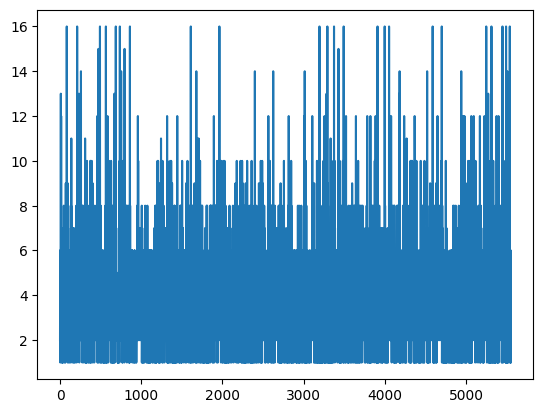

In [199]:
acc = df['accomodates']
acc.plot()

<Axes: >

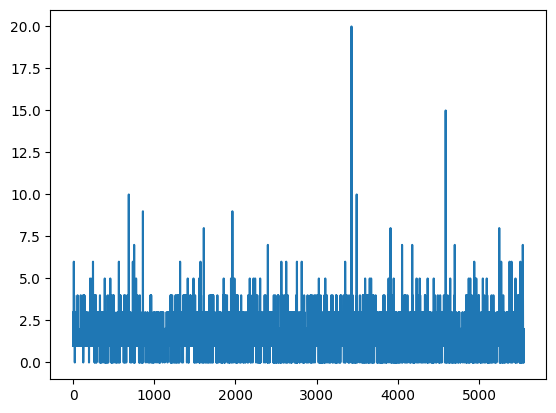

In [200]:
T_bedroom = df['total_bedrooms']
T_bedroom.plot()

<Axes: >

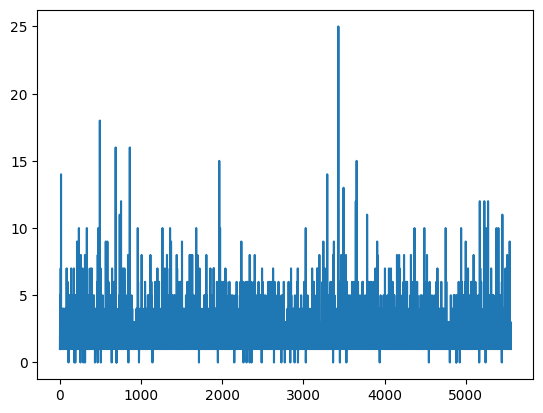

In [201]:
T_bed = df['total_beds']
T_bed.plot()

<Axes: >

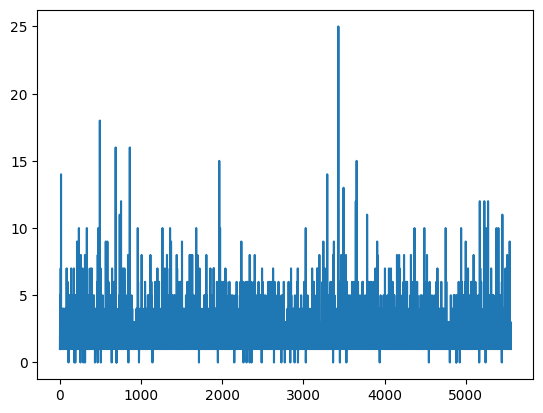

In [202]:
deposit = df['deposit']
deposit.plot()

<Axes: >

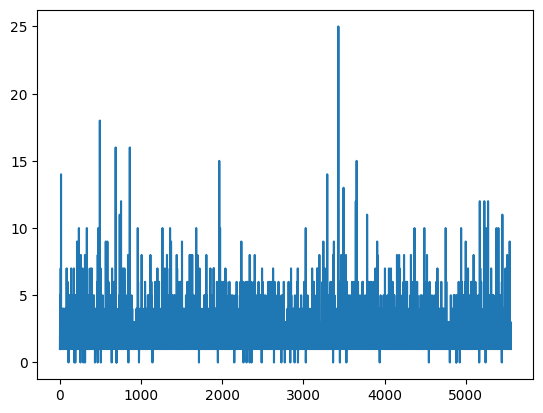

In [203]:
cleaning_fee  = df['cleaning_fee']
cleaning_fee.plot()

<Axes: >

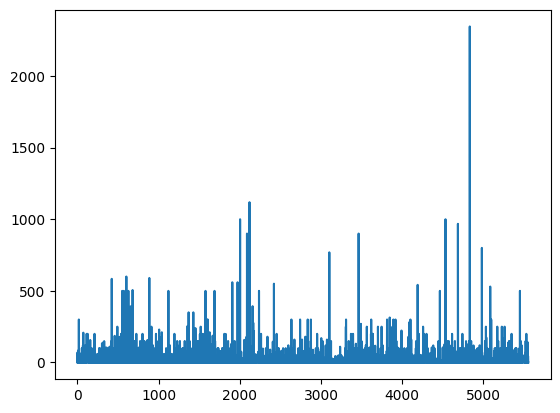

In [204]:
extra_people = df['extra_people']
extra_people.plot()

In [205]:
df['extra_people'].unique()

array([   0,   70,   40,   15,    9,   25,    5,   45,   84,   10,   20,
        300,   12,   30,   35,   29,   65,  100,   50,  119,   80,  208,
         87,  118,   75,   42,   90,   22,   60,   79,  120,  200,   53,
         63,  157,    4,   37,   13,    8,   89,  134,  140,   55,   83,
        149,  105,   17,  112,  150,  584,   23,   14,   76,  186,   24,
         59,  250,   52,  179,   26,  500,  132,  180,  110,  600,  392,
        506,  107,   46,    7,   18,  590,   54,   93,    6,   36,  230,
        175,   66,  211,  102,   32,   98,   58,  255,   31,  350,   68,
        240,  130,  198,   27,   19,  187,  160,   48,  199,   34,  131,
        560,  264,   39, 1000,   28,   49,  158,  900, 1119,   72,   11,
        393,  277,  220,   97,   44,  145,  550,   73,   85,   95,  170,
         21,  769,  270,  101,  117,   16,  314,  223,  280,  542,  125,
        127,  968, 2346,  800,  530,   77])

In [206]:
#delete the above rows
indices_to_drop = df[df['extra_people'] == 2346 ].index
# Drop those indices
df.drop(indices_to_drop, inplace=True)

In [207]:
df.select_dtypes(include='object').nunique()

listing_url            5554
name                   5537
desc                   5442
rules                  3112
property_type            36
room_type                 3
bed_type                  5
cancellation_policy       5
image                  5552
street                  677
suburb                  410
government_area         418
market                   15
country                   9
country_code              9
location_type             1
dtype: int64

In [208]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.shape

(5554, 34)

In [209]:

# Choose only numerical values
is_number = np.vectorize(lambda x: np.issubdtype(x, np.number))
is_number(df.dtypes)

# Correlation matrix
df.loc[:, is_number(df.dtypes)].corr()

,Unnamed: 0_x,property_id,min_nights,max_nights,accomodates,total_bedrooms,total_beds,price,deposit,cleaning_fee,extra_people,guests_included,review_count,Unnamed: 0_y,_id,latitude,longitude
Unnamed: 0_x,1.000000,0.011976,0.004528,0.005763,-0.002116,-0.003972,0.004579,-0.011513,0.004579,0.004579,0.006497,0.017101,-0.034928,1.000000,0.011976,0.032751,0.052533
property_id,0.011976,1.000000,-0.009375,-0.023117,0.002202,-0.021101,-0.015577,0.005874,-0.015577,-0.015577,-0.047154,-0.042393,-0.364419,0.011976,1.000000,0.144591,0.071429
min_nights,0.004528,-0.009375,1.000000,-0.004656,-0.021742,0.009114,-0.019390,-0.010503,-0.019390,-0.019390,-0.033711,-0.023832,-0.060662,0.004528,-0.009375,-0.006503,0.041280
max_nights,0.005763,-0.023117,-0.004656,1.000000,0.001974,-0.010351,0.019001,0.000708,0.019001,0.019001,-0.003399,-0.005428,0.009560,0.005763,-0.023117,0.004113,0.013461
accomodates,-0.002116,0.002202,-0.021742,0.001974,1.000000,0.740189,0.821761,0.152638,0.821761,0.821761,0.071348,0.530017,0.016205,-0.002116,0.002202,-0.114019,-0.070066
total_bedrooms,-0.003972,-0.021101,0.009114,-0.010351,0.740189,1.000000,0.728319,0.143856,0.728319,0.728319,0.027323,0.440357,-0.058632,-0.003972,-0.021101,-0.025900,-0.066624
total_beds,0.004579,-0.015577,-0.019390,0.019001,0.821761,0.728319,1.000000,0.133675,1.000000,1.000000,0.082615,0.459616,-0.009519,0.004579,-0.015577,-0.042704,-0.056367
price,-0.011513,0.005874,-0.010503,0.000708,0.152638,0.143856,0.133675,1.000000,0.133675,0.133675,0.075470,0.048744,-0.065507,-0.011513,0.005874,0.099303,-0.086947
deposit,0.004579,-0.015577,-0.019390,0.019001,0.821761,0.728319,1.000000,0.133675,1.000000,1.000000,0.082615,0.459616,-0.009519,0.004579,-0.015577,-0.042704,-0.056367
cleaning_fee,0.004579,-0.015577,-0.019390,0.019001,0.821761,0.728319,1.000000,0.133675,1.000000,1.000000,0.082615,0.459616,-0.009519,0.004579,-0.015577,-0.042704,-0.056367


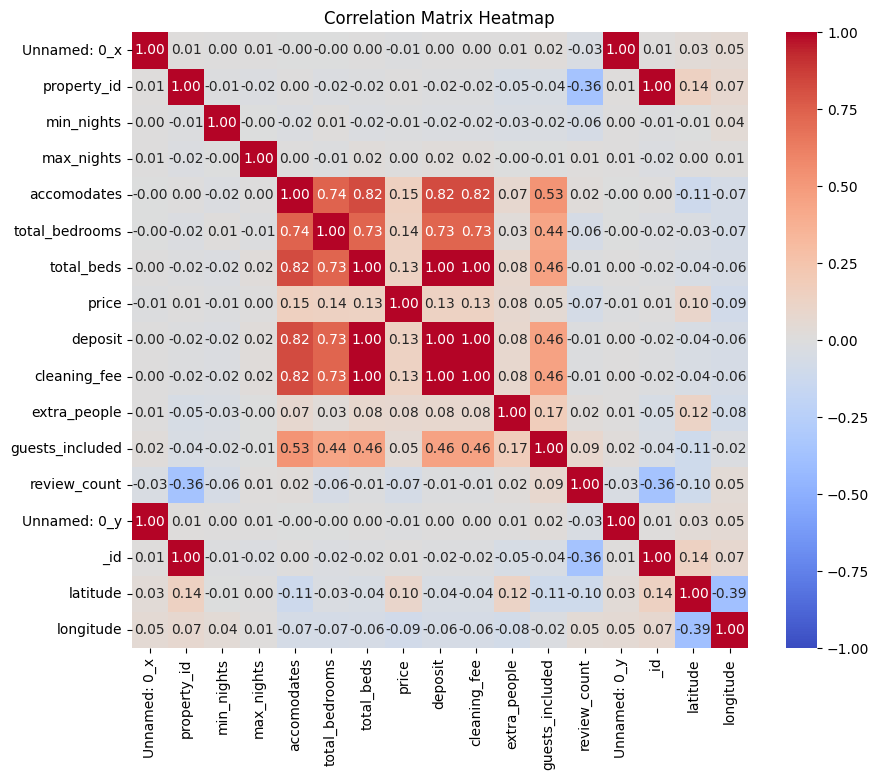

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.sample(5554).loc[:, is_number(df.dtypes)].corr()
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,           # Show the correlation values
            cmap='coolwarm',      # Color scheme
            vmin=-1, vmax=1,      # Set the range of values
            center=0,             # Center the colormap at 0
            square=True,          # Make the plot square-shaped
            fmt='.2f')            # Round the values to 2 decimal places

# Add title
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()


In [211]:
#df.sample(10)

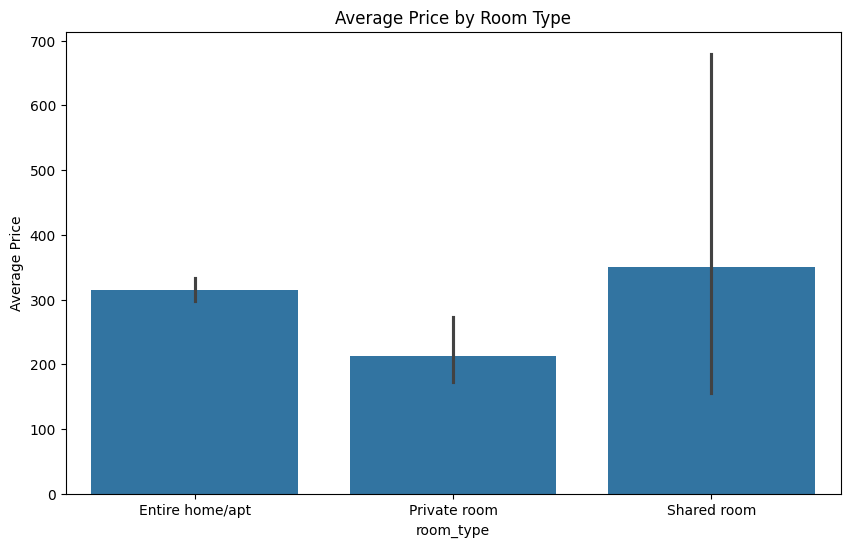

In [212]:
plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price', data=df)
plt.title('Average Price by Room Type')
plt.xlabel('room_type')
plt.ylabel('Average Price')
plt.show()

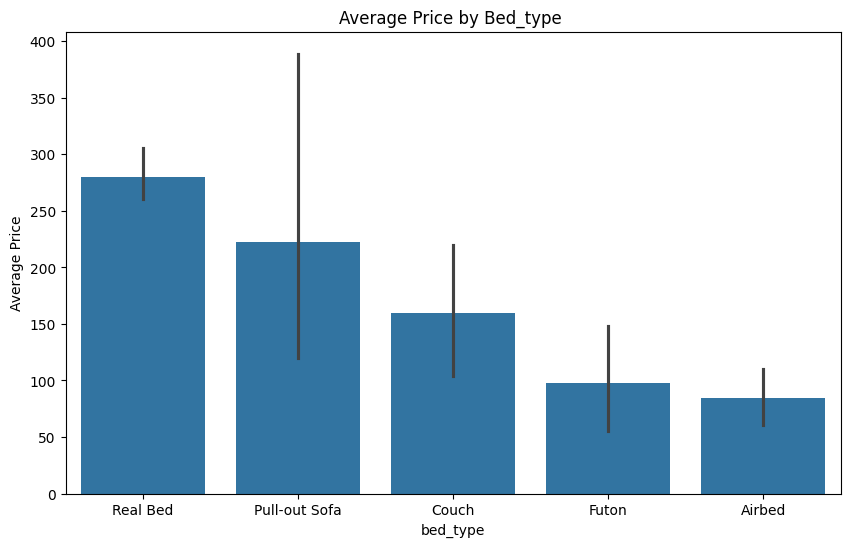

In [213]:
plt.figure(figsize=(10, 6))
sns.barplot(x='bed_type', y='price', data=df)
plt.title('Average Price by Bed_type ')
plt.xlabel('bed_type')
plt.ylabel('Average Price')
plt.show()

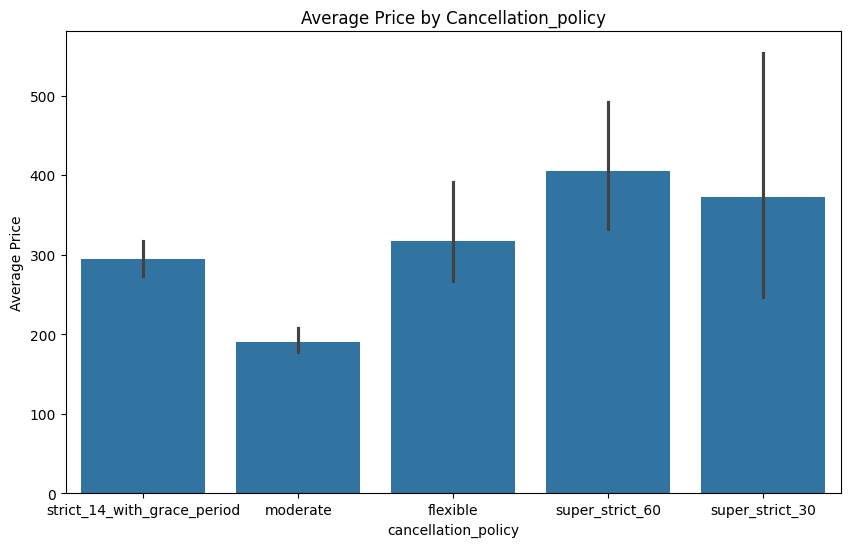

In [214]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cancellation_policy', y='price', data=df)
plt.title('Average Price by Cancellation_policy')
plt.xlabel('cancellation_policy')
plt.ylabel('Average Price')
plt.show()

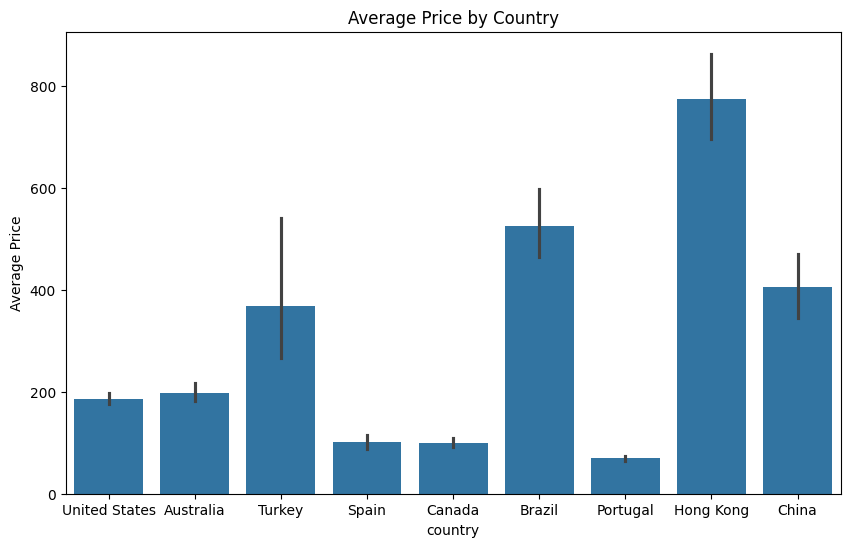

In [215]:
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='price', data=df)
plt.title('Average Price by Country')
plt.xlabel('country')
plt.ylabel('Average Price')
plt.show() 

Feature Engineering

In [216]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#pipeline
from sklearn.pipeline import Pipeline

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [217]:
if 'min_nights' in df.columns:
    df['min_nights'] = df['min_nights'].replace(0, 1)
    df['price_per_night'] = df['price'] / df['min_nights']
else:
    print("Error: 'min_nights' column not found in the DataFrame.")

In [218]:
# Define the list of columns to drop
columns_to_drop = ['Unnamed: 0_x', 'property_id','Unnamed: 0_y', '_id','listing_url', 'name', 'desc', 'rules',
'image','street', 'suburb','government_area', 'market', 'country_code', 'location_type']

# Filter the list to include only columns that exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Drop the existing columns
df = df.drop(existing_columns_to_drop, axis=1)

Create the ColumnTransformer and Applying Machine Learning Model

In [219]:

features = df.drop(['price'], axis=1)

label = df['price'].values


In [220]:
# Your split code here
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.3, random_state=0)



In [221]:
#categorical_features = X_train.select_dtypes(include=['object','int64']).columns
#categorical_features

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist() 

In [222]:
categorical_cols

['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'country']

In [223]:
#numerical_features = X_train.select_dtypes(include=['float64']).columns
#numerical_features 
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.difference(categorical_cols).tolist()

In [224]:
numerical_cols

['accomodates',
 'cleaning_fee',
 'deposit',
 'extra_people',
 'guests_included',
 'latitude',
 'longitude',
 'max_nights',
 'min_nights',
 'price_per_night',
 'review_count',
 'total_bedrooms',
 'total_beds']

In [225]:


#Define your transformers

numerical_transformer = Pipeline(steps=[ 
     ('scaler', StandardScaler())
     #('scaler', StandardScaler(),numerical_cols)
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
     #('onehot', OneHotEncoder(handle_unknown='ignore',), categorical_cols)
     ])    

In [226]:
preprocessor = ColumnTransformer(
   transformers=[
      # ('num', numerical_transformer, numerical_features),
       #('cat', categorical_transformer, categorical_features)
        ('num', numerical_transformer, numerical_cols),
       ('cat', categorical_transformer, categorical_cols)
   ])

In [227]:
Lr_model_1 = Pipeline(steps=[('preprocessor', preprocessor),
                            (' LinearRegression', LinearRegression())])

In [228]:
Lr_model_1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['accomodates',
                                                   'cleaning_fee', 'deposit',
                                                   'extra_people',
                                                   'guests_included',
                                                   'latitude', 'longitude',
                                                   'max_nights', 'min_nights',
                                                   'price_per_night',
                                                   'review_count',
                                                   'total_bedrooms',
                                                   'total_beds']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['property_type', 'room_type',
                                                   'bed_type',
                                                   'cancellation_policy',
                                                   'country'])])),
                (' LinearRegression', LinearRegression())])

In [229]:
model_1_preds = Lr_model_1.predict(X_test)
model_1_preds

array([198.80972291,  81.16792361, 158.96641723, ..., 466.7555415 ,
        -4.77582306, 285.91794246], shape=(1667,))

In [230]:
print('model R2 Score: {}'.format(Lr_model_1.score(X_test, y_test)))

model R2 Score: 0.7422341597409821


In [231]:
print('model MSE: {}'.format(mean_squared_error(y_test,model_1_preds)))

model MSE: 465262.3592666576


In [232]:
print(Lr_model_1[-1].coef_)

[ 2.34055427e+01  2.99122460e+00  2.99122460e+00 -4.04751023e+00
 -7.05396990e+00  2.05640529e+01 -2.88981332e+01 -1.00556518e-01
  1.07165384e+01  3.75196660e+02 -1.83868224e+01  3.89822338e+01
  2.99122460e+00 -9.66958494e+01 -6.51691019e+01 -9.07648484e+01
  1.09837104e+00 -1.24905853e+02 -7.82303907e+01 -7.73041980e+01
 -4.22214382e+01 -1.69032510e+02 -7.28470564e+01  4.71403839e+00
 -1.58716665e+02 -6.35329191e+01 -1.03035802e+02 -2.60467881e+02
 -7.84817307e+01 -8.08247654e+01 -1.49523390e+02  1.72579565e+03
 -8.79117787e+01 -1.15483500e+02 -3.98110081e+01  9.84653743e+02
 -1.22685829e+02 -7.13037273e+01 -9.61038415e+01 -6.27288196e+01
 -3.30706355e+02  1.07516320e+02 -2.38323121e+01 -3.75430603e+01
 -6.39070217e+01 -6.00064714e+01  7.04926175e+01  2.11812500e+00
 -7.26107425e+01 -7.87870319e+01 -3.67135282e+00  3.61738256e+01
  6.70583911e+00  3.95787200e+01 -6.83242437e+00 -3.96624590e+00
 -5.75780540e+00 -2.44153189e+01  4.09717946e+01 -1.00547533e+02
  9.03144255e+01 -3.69431

In [233]:
print(len(Lr_model_1[-1].coef_))

68


In [234]:
from sklearn.linear_model import Ridge

In [235]:
Lr_model_2 = Pipeline(steps=[('preprocessor', preprocessor),
                            ('Lr', Ridge(alpha=0.9))])

In [236]:
Lr_model_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['accomodates',
                                                   'cleaning_fee', 'deposit',
                                                   'extra_people',
                                                   'guests_included',
                                                   'latitude', 'longitude',
                                                   'max_nights', 'min_nights',
                                                   'price_per_night',
                                                   'review_count',
                                                   'total_bedrooms',
                                                   'total_beds']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['property_type', 'room_type',
                                                   'bed_type',
                                                   'cancellation_policy',
                                                   'country'])])),
                ('Lr', Ridge(alpha=0.9))])

In [237]:
model_2_preds = Lr_model_2.predict(X_test)
model_2_preds 

array([200.0649108 ,  83.84223151, 157.92052052, ..., 441.50847579,
        -3.73267524, 287.47769352], shape=(1667,))

In [238]:
print('model R2 Score: {}'.format(Lr_model_2.score(X_test, y_test)))

model R2 Score: 0.7428970820730092


In [239]:
print('model MSE: {}'.format(mean_squared_error(y_test,model_2_preds)))

model MSE: 464065.7972710899
